# 04 - Mentor Assignment (Basic)

Load data -> KMeans risk clusters -> hardcoded mentor ranking -> mentor for one student.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "ml_pipeline").exists() and (ROOT.parent / "ml_pipeline").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
from ml_pipeline import MentorAssigner
from ml_pipeline.config import RISK_ORDER, ASSIGNMENTS_CSV_PATH

plt.rcParams["figure.figsize"] = (12, 5)

## Load data

In [2]:
assigner = MentorAssigner()
df = assigner.load()
print("students:", len(df))
df[["roll_no", "full_name", "class_section", "previous_cgpa"]].head()

students: 46500


,roll_no,full_name,class_section,previous_cgpa
0,210029053348,Aarav Shah,CS-DS,6.47
1,210029035828,Kabir Verma,CS-DS,8.30
2,210029039616,Isha Kumar,IT-A,NaN
3,210029036528,Kabir Bhat,CS-DS,9.73
4,210029010644,Aditya Das,CSE-A,7.97


## Fit (features + KMeans + hardcoded mentor ranking)

In [3]:
assigner.fit(df)
print("clusters:", assigner.group_mapping)


clusters: {2: 'Need Help', 0: 'Fell Down', 3: 'Normal', 1: 'Topper'}


## KMeans: elbow + silhouette

 k  inertia  silhouette
 2  69147.8      0.4126
 3  54391.4      0.2751
 4  45844.9      0.2953
 5  40282.5      0.2443
 6  36179.8      0.2620
 7  32210.9      0.2586
 8  29184.2      0.2631
 9  27278.7      0.2625
10  25659.6      0.2384


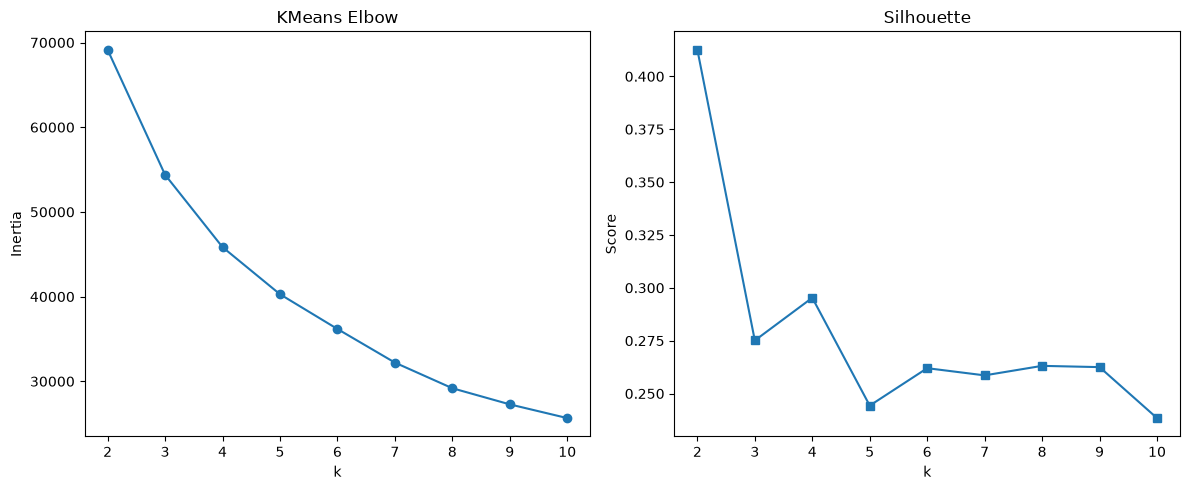

In [4]:
diag = assigner.kmeans_diagnostics(df)
print(diag.to_string(index=False))

fig, ax = plt.subplots(1, 2)
ax[0].plot(diag["k"], diag["inertia"], "o-")
ax[0].set(title="KMeans Elbow", xlabel="k", ylabel="Inertia")
ax[1].plot(diag["k"], diag["silhouette"], "s-")
ax[1].set(title="Silhouette", xlabel="k", ylabel="Score")
plt.tight_layout()
plt.show()

## Risk groups

risk_level
Need Help     4010
Fell Down    17916
Normal        2254
Topper       22320
Name: count, dtype: int64


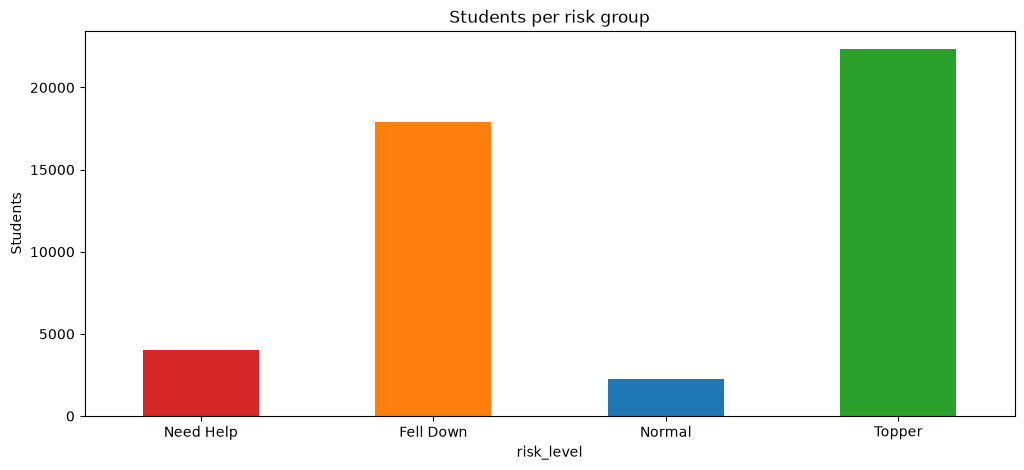

In [5]:
data = assigner.transform(df)
counts = data["risk_level"].value_counts().reindex(RISK_ORDER)
print(counts)

counts.plot(kind="bar", rot=0, color=["#d62728", "#ff7f0e", "#1f77b4", "#2ca02c"])
plt.title("Students per risk group")
plt.ylabel("Students")
plt.show()

## One student: full unit-wise analysis

In [6]:
roll_no = str(data.sort_values("total_weakness", ascending=False).iloc[0]["roll_no"])
result = assigner.analyze_student(roll_no)

print(result["full_name"], "|", result["roll_no"], "|", result["class_section"])
print(result["risk_level"], "| priority", result["priority_rank"])
print(result["recommendation_summary"])

for s in result["subjects"]:
    weak = ", ".join(w["unit"] for w in s["weak_units"]) or "-"
    mentor = (s["mentor"] or {}).get("name", "-")
    print(s["subject"].upper(), s["score_pct"], "% | weak:", weak, "| mentor:", mentor)

Kavya Verma | 210029038252 | CSE-A
Need Help | priority 1
'Need Help' (priority 1). 10 mentor intervention(s) required.
COA 21.8 % | weak: Unit 1, Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Dr. Ananya
MATHS4 33.9 % | weak: Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Prof. Sneha
DSTL 15.8 % | weak: Unit 1, Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Prof. Khan
DS 6.5 % | weak: Unit 1, Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Dr. Kapoor
PYTHON 8.4 % | weak: Unit 1, Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Dr. Nair
CYBER 21.9 % | weak: Unit 1, Unit 2, Unit 3, Unit 4, Unit 5 | mentor: Dr. Malhotra


## Save artifacts

In [7]:
assignments = assigner.assign_all(df, output_path=ASSIGNMENTS_CSV_PATH)
print("mentor assignments:", len(assignments))

Exported 113988 assignments to E:\HAPPY\edu-growth\edu-growth\artifacts\mentor_assign.csv
mentor assignments: 113988
